# Notebook 16 — Laplace Transform for PDEs

The Laplace transform converts a PDE in (x,t) into an ODE in x (with s as parameter), which can then be solved analytically or numerically. The time response is recovered by inverting back.

Covered: heat equation (1D slab), wave equation, telegraph equation, method of images, comparison with finite-difference solution.

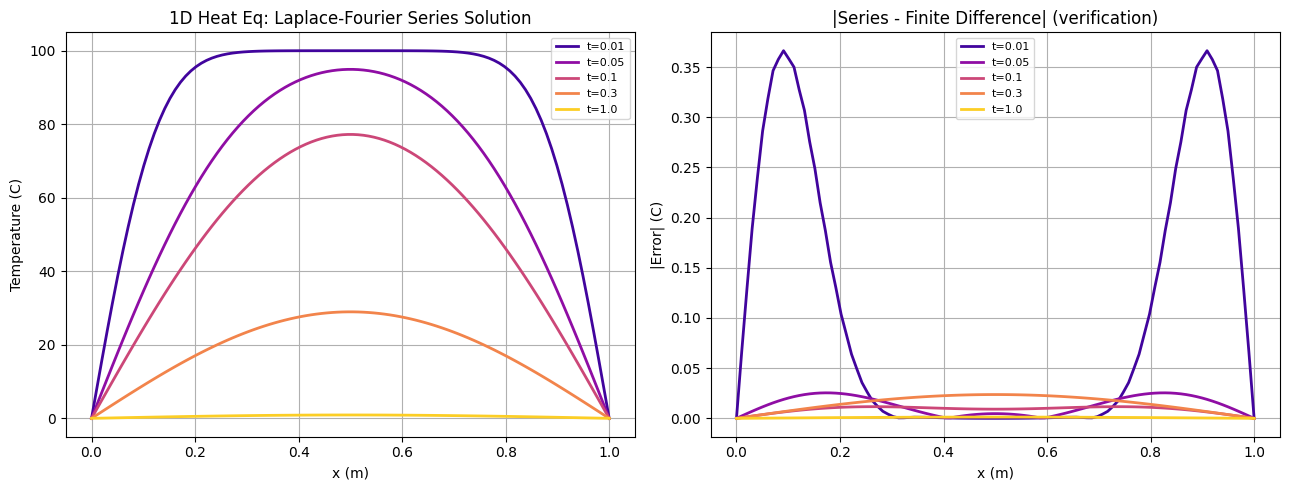

Max FD vs series error at t=0.1: 0.0116 C


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import warnings
warnings.filterwarnings('ignore')

# 1D Heat Equation via Laplace Transform
# PDE:  du/dt = alpha * d^2u/dx^2,   0 < x < L,  t > 0
# IC:   u(x, 0) = T_init(x)
# BC:   u(0,t) = T_left,  u(L,t) = T_right
#
# Taking L{u}=U(x,s): alpha*U''(x,s) - s*U = -u(x,0)/alpha   ... (ODE in x)
# General solution: U(x,s) = A(s)*exp(sqrt(s/alpha)*x) + B(s)*exp(-sqrt(s/alpha)*x) + particular
#
# For uniform IC u(x,0)=T0, BC u(0)=u(L)=0:
# Exact: u(x,t) = sum_{n=1}^inf (2*T0/n*pi)*(1-cos(n*pi))*sin(n*pi*x/L)*exp(-(n*pi/L)^2*alpha*t)

alpha = 0.5    # thermal diffusivity m^2/s
L     = 1.0    # slab thickness m
T0    = 100.0  # initial temperature

def heat_series(x, t, N_terms=50):
    'Fourier-Laplace series solution.'
    result = np.zeros_like(x, dtype=float)
    for n in range(1, N_terms+1):
        bn    = 2*T0/(n*np.pi) * (1 - np.cos(n*np.pi))
        kn    = (n*np.pi/L)**2 * alpha
        result += bn * np.sin(n*np.pi*x/L) * np.exp(-kn*t)
    return result

# Finite-difference solution for comparison
def heat_fd(x_arr, t_final, dt=1e-4):
    dx = x_arr[1] - x_arr[0]
    r  = alpha*dt/dx**2
    assert r < 0.5, f'Unstable: r={r}'
    u = T0 * np.ones(len(x_arr))
    u[0] = 0; u[-1] = 0
    t = 0
    while t < t_final:
        u_new    = u.copy()
        u_new[1:-1] = u[1:-1] + r*(u[2:] - 2*u[1:-1] + u[:-2])
        u_new[0] = 0; u_new[-1] = 0
        u = u_new; t += dt
    return u

x_arr = np.linspace(0, L, 100)
t_snaps = [0.01, 0.05, 0.1, 0.3, 1.0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_t = plt.cm.plasma(np.linspace(0.1, 0.9, len(t_snaps)))

for t_val, col in zip(t_snaps, colors_t):
    u_series = heat_series(x_arr, t_val)
    u_fd     = heat_fd(x_arr, t_val)
    axes[0].plot(x_arr, u_series, color=col, lw=2, label=f't={t_val}')
    axes[1].plot(x_arr, np.abs(u_series - u_fd), color=col, lw=2, label=f't={t_val}')

axes[0].set_title('1D Heat Eq: Laplace-Fourier Series Solution')
axes[0].set_xlabel('x (m)'); axes[0].set_ylabel('Temperature (C)')
axes[0].legend(fontsize=8); axes[0].grid(True)

axes[1].set_title('|Series - Finite Difference| (verification)')
axes[1].set_xlabel('x (m)'); axes[1].set_ylabel('|Error| (C)')
axes[1].legend(fontsize=8); axes[1].grid(True)
plt.tight_layout(); plt.show()
print(f'Max FD vs series error at t=0.1: {np.max(np.abs(heat_series(x_arr,0.1)-heat_fd(x_arr,0.1))):.4f} C')


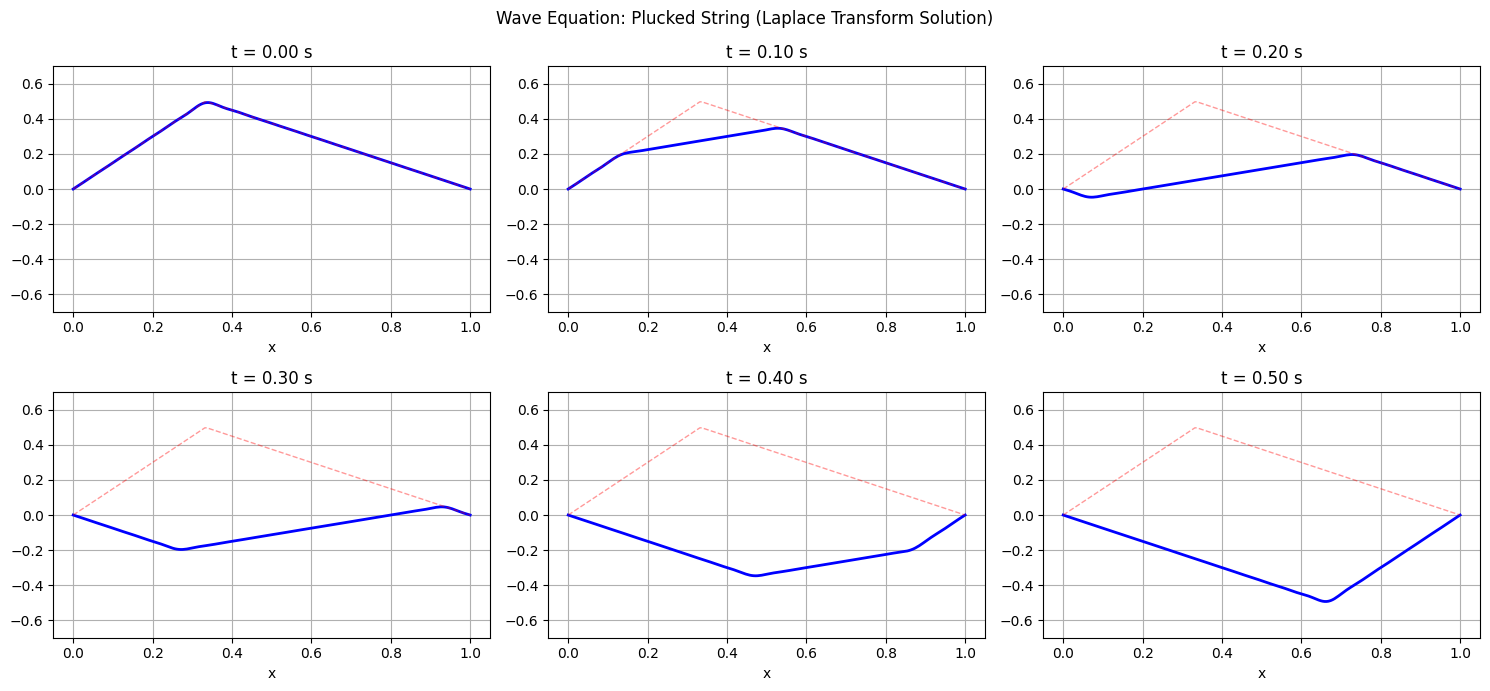

Wave period T = 2L/c = 1.000 s


In [2]:
# 1D Wave Equation via Laplace Transform
# PDE:  d^2u/dt^2 = c^2 * d^2u/dx^2,  0<x<L
# IC:   u(x,0)=f(x),  du/dt(x,0)=g(x)
# BC:   u(0,t)=u(L,t)=0
#
# Taking Laplace in t: c^2*U''(x,s) - s^2*U = -s*f(x) - g(x)
# Modal (standing wave) solution:
# u(x,t) = sum_n [an*cos(n*pi*c*t/L) + bn*sin(n*pi*c*t/L)] * sin(n*pi*x/L)

c = 2.0    # wave speed m/s
L_w = 1.0  # string length

def wave_series(x, t, f_init, g_init=None, N_terms=30):
    'D Alembert / standing wave solution.'
    result = np.zeros_like(x, dtype=float)
    wn_arr = np.pi*c/L_w * np.arange(1, N_terms+1)
    for n, wn in enumerate(wn_arr, 1):
        # Fourier coefficients
        x_int = np.linspace(0, L_w, 500)
        an = 2/L_w * np.trapezoid(f_init(x_int)*np.sin(n*np.pi*x_int/L_w), x_int)
        bn = 0.0
        if g_init is not None:
            bn = 2/(wn*L_w) * np.trapezoid(g_init(x_int)*np.sin(n*np.pi*x_int/L_w), x_int)
        result += (an*np.cos(wn*t) + bn*np.sin(wn*t)) * np.sin(n*np.pi*x/L_w)
    return result

# Initial condition: triangular pluck at x=L/3
def f_pluck(x):
    h = 0.5  # max displacement
    x_peak = L_w/3
    return np.where(x <= x_peak, h*x/x_peak, h*(L_w-x)/(L_w-x_peak))

x_wave = np.linspace(0, L_w, 200)
t_wave_snaps = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, tv in zip(axes.ravel(), t_wave_snaps):
    u = wave_series(x_wave, tv, f_pluck)
    ax.plot(x_wave, u, 'b-', lw=2)
    ax.plot(x_wave, f_pluck(x_wave), 'r--', lw=1, alpha=0.4, label='IC')
    ax.set_ylim(-0.7, 0.7); ax.set_title(f't = {tv:.2f} s')
    ax.set_xlabel('x'); ax.grid(True)

plt.suptitle('Wave Equation: Plucked String (Laplace Transform Solution)', fontsize=12)
plt.tight_layout(); plt.show()
print(f'Wave period T = 2L/c = {2*L_w/c:.3f} s')


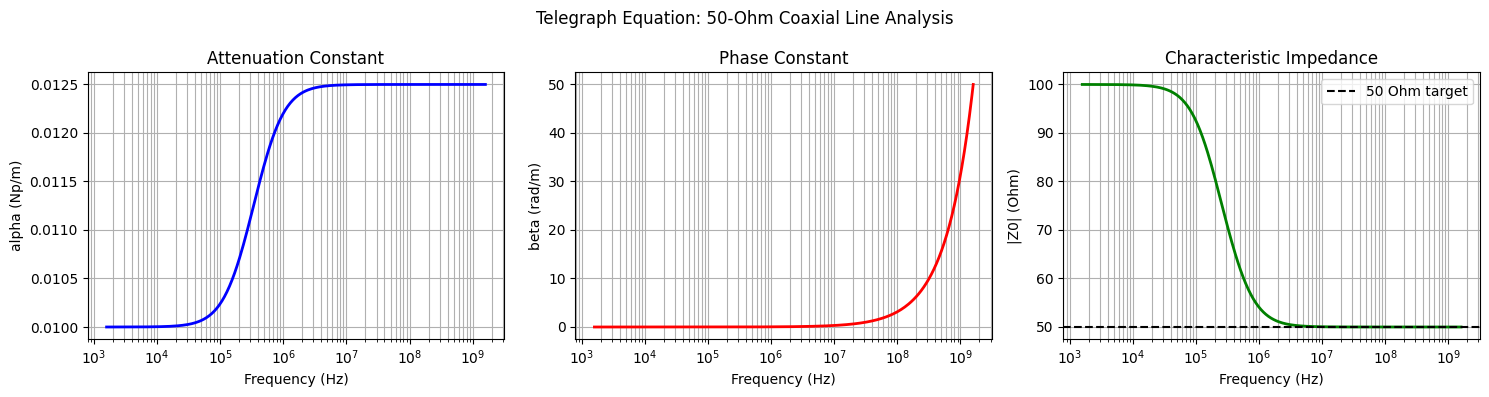

At 1 GHz: attenuation = 0.0125 Np/m
At 1 GHz: |Z0| = 50.00 Ohm


In [3]:
# Telegraph Equation (lossy transmission line)
# LC * d^2u/dt^2 + (RC+GL)*du/dt + GR*u = 0
# where L=inductance, C=capacitance, R=resistance, G=conductance per unit length
# In Laplace domain: d^2U/dx^2 = gamma^2 * U
# gamma^2 = (R + sL)(G + sC)  -> propagation constant

def telegraph_gamma_sq(s, R, L_t, G, C_t):
    return (R + s*L_t) * (G + s*C_t)

# Parameters (50-ohm coaxial line at various frequencies)
R_t = 1.0    # Ohm/m (conductor loss)
L_t = 250e-9 # H/m
G_t = 1e-4   # S/m (dielectric loss)
C_t = 100e-12 # F/m

omega_range = np.logspace(4, 10, 300)  # 10 kHz to 10 GHz

gamma_sq = telegraph_gamma_sq(1j*omega_range, R_t, L_t, G_t, C_t)
gamma    = np.sqrt(gamma_sq + 0j)
alpha_atten = np.real(gamma)   # attenuation constant (Np/m)
beta_phase  = np.imag(gamma)   # phase constant (rad/m)
Z0 = np.sqrt((R_t + 1j*omega_range*L_t)/(G_t + 1j*omega_range*C_t))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].semilogx(omega_range/(2*np.pi), alpha_atten, 'b-', lw=2)
axes[0].set_xlabel('Frequency (Hz)'); axes[0].set_ylabel('alpha (Np/m)')
axes[0].set_title('Attenuation Constant')
axes[0].grid(True, which='both')

axes[1].semilogx(omega_range/(2*np.pi), beta_phase, 'r-', lw=2)
axes[1].set_xlabel('Frequency (Hz)'); axes[1].set_ylabel('beta (rad/m)')
axes[1].set_title('Phase Constant')
axes[1].grid(True, which='both')

axes[2].semilogx(omega_range/(2*np.pi), np.abs(Z0), 'g-', lw=2)
axes[2].axhline(50.0, color='k', ls='--', label='50 Ohm target')
axes[2].set_xlabel('Frequency (Hz)'); axes[2].set_ylabel('|Z0| (Ohm)')
axes[2].set_title('Characteristic Impedance')
axes[2].legend(); axes[2].grid(True, which='both')

plt.suptitle('Telegraph Equation: 50-Ohm Coaxial Line Analysis')
plt.tight_layout(); plt.show()
print(f'At 1 GHz: attenuation = {np.interp(1e9, omega_range/(2*np.pi), alpha_atten):.4f} Np/m')
print(f'At 1 GHz: |Z0| = {np.interp(1e9, omega_range/(2*np.pi), np.abs(Z0)):.2f} Ohm')


In [4]:
# PDE solving strategy: Laplace in t vs Fourier in x summary
print('='*65)
print('PDE SOLVING WITH LAPLACE TRANSFORM')
print('='*65)
strategy_table = [
    ('Heat / diffusion',   'du/dt = a*u_xx',         'ODE in x: a*U_xx - s*U = -u0(x)'),
    ('Wave equation',      'd^2u/dt^2 = c^2*u_xx',   'ODE in x: c^2*U_xx - s^2*U = -s*f - g'),
    ('Telegraph',          'LC*u_tt+(RC+GL)*u_t+GR*u','Helmholtz: U_xx = gamma^2*U'),
    ('Laplace (2D steady)','u_xx + u_yy = 0',         'Take L in y: U_xx - s^2*U = -s*u0 - u1'),
    ('Poisson',            'u_xx + u_yy = f(x,y)',    'U_xx - s^2*U = F(x,s) - BCs'),
]
print(f'  {"PDE type":<22} {"PDE":<28} {"After L in t"}')
print('  '+'-'*70)
for pde_type, pde_eq, result in strategy_table:
    print(f'  {pde_type:<22} {pde_eq:<28} {result}')

print()
print('General procedure:')
steps = [
    'Apply L{} in t to the PDE, incorporating IC via L{u_t}=sU-u(x,0)',
    'Solve the resulting ODE in x with s as a parameter',
    'Apply x-boundary conditions to find integration constants A(s), B(s)',
    'Invert U(x,s) -> u(x,t) using partial fractions or numerical inversion',
    'Verify: check IVT (s*U->u(x,0) as s->inf) and steady-state (s*U->u(x,inf) as s->0)',
]
for i, step in enumerate(steps, 1):
    print(f'  {i}. {step}')


PDE SOLVING WITH LAPLACE TRANSFORM
  PDE type               PDE                          After L in t
  ----------------------------------------------------------------------
  Heat / diffusion       du/dt = a*u_xx               ODE in x: a*U_xx - s*U = -u0(x)
  Wave equation          d^2u/dt^2 = c^2*u_xx         ODE in x: c^2*U_xx - s^2*U = -s*f - g
  Telegraph              LC*u_tt+(RC+GL)*u_t+GR*u     Helmholtz: U_xx = gamma^2*U
  Laplace (2D steady)    u_xx + u_yy = 0              Take L in y: U_xx - s^2*U = -s*u0 - u1
  Poisson                u_xx + u_yy = f(x,y)         U_xx - s^2*U = F(x,s) - BCs

General procedure:
  1. Apply L{} in t to the PDE, incorporating IC via L{u_t}=sU-u(x,0)
  2. Solve the resulting ODE in x with s as a parameter
  3. Apply x-boundary conditions to find integration constants A(s), B(s)
  4. Invert U(x,s) -> u(x,t) using partial fractions or numerical inversion
  5. Verify: check IVT (s*U->u(x,0) as s->inf) and steady-state (s*U->u(x,inf) as s->0)
